# Plane Geometry and Randomness #10

### 2D geometry, randomness



### Generating random 2 - dimensional vectors
* np.random.rand (uniform distribution is segment [0,1])
* np.random.randn (normal distribution)

In [3]:
import numpy as np
import matplotlib.pyplot as plt # for plotting
np.random.seed(0) # USEFUL !

# this is optimal, but this way everyone will be getting
# the same sequences of (pseudo) random numbers

NUM_VECTORS = 10_000 # convention for naming constants in python!

np.random.seed(0)
it makes "random" results repeatable.

without this line > different random numbers every run
with this line > the same random numbers every run

In [4]:
p = np.random.rand(2) # this gives us a single 2-dimensional vector

# np.random.rand(2)> generate 2 random numbers between 0 and 1.

print(p)
type(p)

[0.5488135  0.71518937]


numpy.ndarray

numpy.ndarray > numpy array, opimized for math and geometry

### Generating many vectors -- back to speed of python/numpy

In [5]:
%lsmagic

Available line magics:
%alias  %alias_magic  %autoawait  %autocall  %automagic  %autosave  %bookmark  %cat  %cd  %clear  %code_wrap  %colors  %conda  %config  %connect_info  %cp  %debug  %dhist  %dirs  %doctest_mode  %ed  %edit  %env  %gui  %hist  %history  %killbgscripts  %ldir  %less  %lf  %lk  %ll  %load  %load_ext  %loadpy  %logoff  %logon  %logstart  %logstate  %logstop  %ls  %lsmagic  %lx  %macro  %magic  %mamba  %man  %matplotlib  %micromamba  %mkdir  %more  %mv  %notebook  %page  %pastebin  %pdb  %pdef  %pdoc  %pfile  %pinfo  %pinfo2  %pip  %popd  %pprint  %precision  %prun  %psearch  %psource  %pushd  %pwd  %pycat  %pylab  %qtconsole  %quickref  %recall  %rehashx  %reload_ext  %rep  %rerun  %reset  %reset_selective  %rm  %rmdir  %run  %save  %sc  %set_env  %store  %sx  %system  %tb  %time  %timeit  %unalias  %unload_ext  %who  %who_ls  %whos  %xdel  %xmode

Available cell magics:
%%!  %%HTML  %%SVG  %%bash  %%capture  %%code_wrap  %%debug  %%file  %%html  %%javascript  %%js  %

In [8]:

%%time
P = [np.random.rand(2) for i in range(NUM_VECTORS)]

CPU times: user 7.97 ms, sys: 5.57 ms, total: 13.5 ms
Wall time: 13.9 ms


In [11]:
%%time
P = np.random.rand(NUM_VECTORS, 2) # returns a 2-dimensional np.array


# this is actually faster.

CPU times: user 345 µs, sys: 1.41 ms, total: 1.76 ms
Wall time: 20.1 ms


### Shape

whatever you create an array of vectors, you specify its shape.

namely the number of rows and columns.

the shape also determines how you can index your array.

In [10]:
P = np.random.rand(10, 2) # ten two-dimensional vectors
print(P.shape)
print(P[9][1])

(10, 2)
0.5963210518386777


- P = np.random.rand(10, 2)

it means, 10 rows and 2 columns

- print(P.shape)

so, the output (10, 2) = (rows, columns)

= (number of vectors, vevtor dimension)


- print(P[9][1])

so 10th vector (indexing starts at 0!) and second coordinate of that vector

### Indexing of 2D numpy arrays, getting rows

In [24]:
print(P)

print(len(P))

[[0.80354331 0.66744234]
 [0.51242426 0.1437468 ]
 [0.39902569 0.11828575]
 ...
 [0.06860983 0.45601225]
 [0.9451891  0.17636708]
 [0.08282849 0.60873855]]
10000


In [17]:
first_vector = P[0] # get initial row (representing a 2D vector here)
last_vector = P[-1] # get lat row

# single two-dimensional vector
print(first_vector)
print(last_vector)

print(P[0,1])
print(P[0][1])

[0.80354331 0.66744234]
[0.08282849 0.60873855]
0.667442340319061
0.667442340319061


### Caveat: comparing arrays

In [19]:
# assert first_vector != last_vector # ERROR!
print("first!=second?\t", first_vector != last_vector) # not what we want
assert (first_vector != last_vector).any() # this gives a single true/false


# assert -> comparision -> return true/false

first!=second?	 [ True  True]


In [20]:
print((first_vector != last_vector.any()))

[ True  True]


In [21]:
print((first_vector == last_vector.any))

[False False]


### Extracting colums

In [23]:
x_coordinates = P[:, 0] # take all (:) rows, then select only the 0th column
y_coordinates = P[:, 1] # take all rows and select the first column

print(x_coordinates, len(x_coordinates))
print(y_coordinates, len(y_coordinates))

[0.80354331 0.51242426 0.39902569 ... 0.06860983 0.9451891  0.08282849] 10000
[0.66744234 0.1437468  0.11828575 ... 0.45601225 0.17636708 0.60873855] 10000


so, question.

what this code is doing?

we already wrote > P.shape  == (10000, 2) > meaning 10,000 points, each point = (x,y)

this code splits the points into x-values and y-values

* P -> the whole awway
* : -> take all rows
* 0 -> take column 0

> from every vector, take the first value (x). a 1D array of all x-values

* P -> the whole awway
* : -> take all rows
* 0 -> take second column (y)

> from every vector, take the y-value

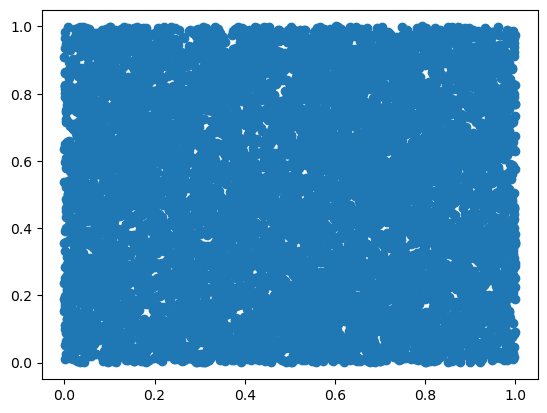

In [25]:
plt.scatter(x_coordinates, y_coordinates)

### Operating on whole arrays

In [26]:
X = P*10 + 5
print(P[0], "=>", X[0])
print(P[1], "=>", X[1])

[0.80354331 0.66744234] => [13.03543313 11.6744234 ]
[0.51242426 0.1437468 ] => [10.12424262  6.43746797]


### Computing the norm of each row (or one the dreaded 'axis' parameter)

recall that the norm of a vector is its length. you can compute the Euclidean norm using np.linalg.norm. The distance between two vectors u, v is the norm of the vector u-v.

to do this you need specify the 'direction' using 'axis' argument. axis=1 means rows. 

In [32]:
lengths = np.linalg.norm(P, axis=1)
print(lengths)
assert len(lengths) == len(P)

[1.04458659 0.53220463 0.41618868 ... 0.46114475 0.96150288 0.61434777]


In [34]:
np.linalg.norm(P, axis=1)

array([1.04458659, 0.53220463, 0.41618868, ..., 0.46114475, 0.96150288,
       0.61434777])

### Array transposition


normally we will think about 2D arrays as sequences of vectors, so each row is a single vector. often it makes sense to reverse this and restructure the data so that each column is a vector. array transposition is the operation which does that. for 2d arrays it works exactly the same as matrix transportation in mathematics.

In [42]:
print(P.shape)
P_transposed = P.T
print(P_transposed.shape) # flipped shape!

xs = P_transposed[0] # initial column of P
print(xs)

ys = P.T[1] # we actually don't need the extra variable
print(ys)



(10000, 2)
(2, 10000)
[0.80354331 0.51242426 0.39902569 ... 0.06860983 0.9451891  0.08282849]
[0.66744234 0.1437468  0.11828575 ... 0.45601225 0.17636708 0.60873855]


### Visualizaing vectors as points on the plane (plt.scatter)

we would like to sample the box [-1,1]^2 and visualize the results.
> in other words each coordinate (x,y) should be between -1 and 1

<function matplotlib.pyplot.scatter(x: 'float | ArrayLike', y: 'float | ArrayLike', s: 'float | ArrayLike | None' = None, c: 'Sequence[ColorType] | ColorType | None' = None, marker: 'MarkerType | None' = None, cmap: 'str | Colormap | None' = None, norm: 'str | Normalize | None' = None, vmin: 'float | None' = None, vmax: 'float | None' = None, alpha: 'float | None' = None, linewidths: 'float | Sequence[float] | None' = None, *, edgecolors: "Literal['face', 'none'] | ColorType | Sequence[ColorType] | None" = None, plotnonfinite: 'bool' = False, data=None, **kwargs) -> 'PathCollection'>

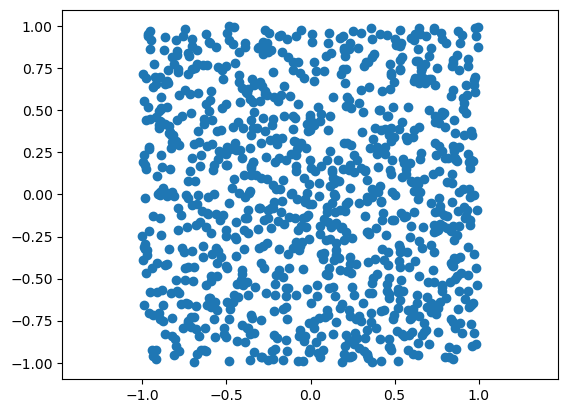

In [59]:
# P = np.random.rand(1000, 2)
# P = P*2 -1 

# plt.axis('equal')

# xs = P[:, 0]
# ys = P[:, 1]
# plt.scatter(xs, ys)


# more efficient ways:

E = np.random.rand(1000, 2)
E = E*2 -1
plt.axis('equal')
# plt.scatter(E.T[0], E.T[1])

plt.scatter(*E.T) # just a trick, it unpacks E.T as two vectors and pushes them
# as the two arguments. useful idiom > plt.scatter(E.T[0], E.T[1]) same trick.

plt.scatter 

### Selecting subarrays

suppose we want to select the rows of our array meeting some criterion
for example, we want only the points with the y coordinate greater than 0.5

In [65]:
X = np.random.rand(3,2) # 3 vectors, 2-dimension 
print(X)

print(X[[True, False, True]]) # we can index with a True/False array!

X[(True, False, True)] # but not with tuples, that's sth. different

[[0.74574984 0.86883315]
 [0.8388094  0.24084193]
 [0.32610115 0.66835604]]
[[0.74574984 0.86883315]
 [0.32610115 0.66835604]]


array([], shape=(0, 3, 2), dtype=float64)

In [66]:
X = np.random.rand(1000,2)

In [73]:
which_rows = X[:, 1] > 0.5 # we ask: which y coords are > 0.5?
#X[:, y-coordinates]

print(which_rows[:10], "...", which_rows.shape)
# we get an array of True/False values!
B = X[which_rows] # just rows corresponding to True in which_rows
how_many_true = np.sum(which_rows) # how many were true? True == 1
assert len(B) == how_many_true # ! # asseration (True/False)

[ True  True False False False False  True  True  True  True] ... (1000,)
